## Import Libraries and Functions

In [1]:
import importlib
from pathlib import Path

import pandas as pd
from IPython.display import display

import hierarchical_position_classifier as hpc_module

importlib.reload(hpc_module)

from hierarchical_position_classifier import (
    combine_position_experiment_summaries,
    per_room_hierarchical_summary,
    run_global_position_experiments_by_split,
    run_hierarchical_position_experiments_by_split,
    summarize_distance_errors,
)
from utils.csi_preprocessing import process_magnitude_data
from utils.feature_pipeline import build_frequency_feature_dataframes
import utils.graphs as graphs

importlib.reload(graphs)

from utils.graphs import (
    plot_band_error_boxplot,
    plot_band_error_cdf,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_position_confusion_by_true_room,
    plot_position_confusion_when_room_correct,
)
from utils.import_data import get_csv_files, sort_meta_info
from utils.thesis_csv_processing import process_csv_files
from utils.cache import get_all_dataframes, get_results_path, save_summary, write_manifest


## Configuration

In [17]:
PROJECT_ROOT = Path(r"C:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project")
DATA_DIR = PROJECT_ROOT / "CSI DATA"
CALIBRATION_MODE = "none"

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "apply_agc_compensation": False,
    "agc_reference": "median",
    "filter_method": "none",
    "filter_window": 5,
    "normalization": "none",
    "epsilon": 1e-8,
}

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": 120,
    "overlap_size": 30,
    "calibrate": False,
    "require_all_esps": False,
}

# ESP-to-room assignment for the local-ESP hierarchical classifier.
ROOM_LOCAL_ESPS = {
    1: (
        "esp_06", "esp_07", "esp_08", "esp_09", "esp_10",
        "esp_16", "esp_17", "esp_18", "esp_19", "esp_20",
    ),
    2: ("esp_01", "esp_02", "esp_03", "esp_11", "esp_12", "esp_13"),
    3: ("esp_04", "esp_05", "esp_14", "esp_15"),
}

# Experiment parameters.
SPLIT_MODES = ("group", "random")
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0

# Dataset shown in confusion matrix and floor plan cells.
CONFUSION_DATASET = "Fusion"   # "2.4 GHz", "5 GHz", or "Fusion"

# Toggle plot sections.
SHOW_CDF_PLOTS = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = False
SHOW_PER_ROOM_PLOTS = False

# ── Derived cache / results paths ────────────────────────────────────────────
preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)

results_dir = get_results_path(preproc_opts, feat_opts)
plots_dir = results_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)


def _slugify(s: str) -> str:
    return (
        s.lower()
        .replace(".", "-")
        .replace(" ", "-")
        .replace("(", "")
        .replace(")", "")
        .strip("-")
    )


## Data Loading and Preprocessing

In [18]:
all_data_files = get_csv_files(str(DATA_DIR))
scenarios_id, locations_id, users_id, esps_id, trials_id = sort_meta_info(str(DATA_DIR))
print(f"Scenarios present: {', '.join(scenarios_id) or 'none'}")
print(f"Locations: {len(locations_id)}  |  Users: {len(users_id)}  |  ESPs: {len(esps_id)}")

Scenarios present: 1
Locations: 53  |  Users: 5  |  ESPs: 19


#### Get magnitude data

In [19]:
magnitude_data, agc_gain_data, csv_diagnostics = process_csv_files(
    all_data_files,
    return_diagnostics=True,
    calibration_mode=CALIBRATION_MODE,
    **CSV_PROCESSING_OPTIONS,
)

#### Segment data, extract features, and create 3 dataframes

In [20]:
def _build_feature_dataframes():
    processed, _ = process_magnitude_data(magnitude_data, agc_gain_data, **preproc_opts)
    return build_frequency_feature_dataframes(processed, **feat_opts)


feature_dataframes = get_all_dataframes(preproc_opts, feat_opts, _build_feature_dataframes)
df_24ghz = feature_dataframes["2.4 GHz"]
df_5ghz = feature_dataframes["5 GHz"]
df_fusion = feature_dataframes["Fusion"]

for name, df in feature_dataframes.items():
    print(f"{name}: {df.shape[0]} windows, {df.shape[1]} columns")

[cache miss] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win120-step30, computing...
2.4 GHz: 5064 windows, 2708 columns
5 GHz: 5364 windows, 3368 columns
Fusion: 5048 windows, 6068 columns


## Experiments

### Global Position Classifier

In [21]:
global_summary, global_preds_by_split, global_models_by_split = (
    run_global_position_experiments_by_split(
        feature_dataframes,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
    )
)
display(global_summary)

,dataset,split,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples
0,2.4 GHz,group,0.097625,2.361008,1.414214,3.228373,1516.0
1,5 GHz,group,0.079926,1.768478,1.414214,2.126458,1614.0
2,Fusion,group,0.106693,1.703182,1.000000,2.195150,1509.0
3,2.4 GHz,random,0.923026,0.187096,0.000000,0.857263,1520.0
4,5 GHz,random,0.917391,0.170371,0.000000,0.751608,1610.0
5,Fusion,random,0.964356,0.076637,0.000000,0.555167,1515.0


### Hierarchical Position Classifier — Local ESPs

In [22]:
hier_local_summary, hier_local_preds, hier_local_models = (
    run_hierarchical_position_experiments_by_split(
        feature_dataframes,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
        esp_mode="local",
        room_local_esps=ROOM_LOCAL_ESPS,
    )
)
display(hier_local_summary)

,dataset,split,esp_mode,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,distance_error_samples,localization_samples,samples
0,2.4 GHz,group,local,0.854222,0.079156,2.982390,2.000000,4.074925,1476.0,1476.0,1516.0
1,5 GHz,group,local,0.941140,0.084263,1.957112,1.414214,2.522579,1574.0,1574.0,1614.0
2,Fusion,group,local,0.941021,0.115971,1.835791,1.414214,2.413539,1470.0,1470.0,1509.0
3,2.4 GHz,random,local,0.969737,0.841447,0.464706,0.000000,1.666488,1490.0,1490.0,1520.0
4,5 GHz,random,local,0.993168,0.877640,0.244618,0.000000,0.884465,1580.0,1580.0,1610.0
5,Fusion,random,local,0.988119,0.918812,0.178682,0.000000,0.829588,1485.0,1486.0,1515.0


## Summary Table

In [23]:
combined_summary = combine_position_experiment_summaries(
    global_summary,
    hier_local_summary,
    pd.DataFrame(),
)
display(combined_summary)
save_summary(combined_summary, results_dir)


,dataset,model,split,room,esp_mode,position_accuracy,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples
0,2.4 GHz,global_position_rf,group,all,all,0.097625,NaN,2.361008,1.414214,3.228373,1516.0
1,5 GHz,global_position_rf,group,all,all,0.079926,NaN,1.768478,1.414214,2.126458,1614.0
2,Fusion,global_position_rf,group,all,all,0.106693,NaN,1.703182,1.000000,2.195150,1509.0
3,2.4 GHz,global_position_rf,random,all,all,0.923026,NaN,0.187096,0.000000,0.857263,1520.0
4,5 GHz,global_position_rf,random,all,all,0.917391,NaN,0.170371,0.000000,0.751608,1610.0
5,Fusion,global_position_rf,random,all,all,0.964356,NaN,0.076637,0.000000,0.555167,1515.0
6,2.4 GHz,hierarchical_rf,group,all,local,0.079156,0.854222,2.982390,2.000000,4.074925,1516.0
7,5 GHz,hierarchical_rf,group,all,local,0.084263,0.941140,1.957112,1.414214,2.522579,1614.0
8,Fusion,hierarchical_rf,group,all,local,0.115971,0.941021,1.835791,1.414214,2.413539,1509.0
9,2.4 GHz,hierarchical_rf,random,all,local,0.841447,0.969737,0.464706,0.000000,1.666488,1520.0


[results] Summary saved to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win120-step30/


## Localization Error Analysis

In [24]:
# Concatenate all predictions for each model, preserving the dataset and split columns.
def _concat_preds(preds_dict: dict, model_label: str) -> pd.DataFrame:
    frames = [df.assign(model=model_label) for df in preds_dict.values() if not df.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


global_all = _concat_preds(global_preds_by_split, "Global")
hier_local_all = _concat_preds(hier_local_preds, "Hierarchical (local)")

In [25]:
# Distance error summary statistics per split.
all_preds = pd.concat([global_all, hier_local_all], ignore_index=True)

for split_mode in SPLIT_MODES:
    print(f"\n=== {split_mode} split ===")
    display(summarize_distance_errors(all_preds.loc[all_preds["split"] == split_mode]))


=== group split ===


,dataset,samples,mean_error,median_error,rmse_error,p75_error,p90_error,max_error
0,2.4 GHz,2932,2.673819,2.000000,3.678966,3.162278,6.000000,13.601471
1,5 GHz,3132,1.863277,1.414214,2.333949,2.236068,3.162278,12.083046
2,Fusion,2915,1.770056,1.414214,2.307866,2.236068,3.605551,12.083046



=== random split ===


,dataset,samples,mean_error,median_error,rmse_error,p75_error,p90_error,max_error
0,2.4 GHz,2980,0.325901,0.0,1.325157,0.0,1.0,13.152946
1,5 GHz,3159,0.207506,0.0,0.820750,0.0,1.0,13.038405
2,Fusion,2971,0.127642,0.0,0.705797,0.0,0.0,13.000000


### CDF — distance error by frequency band

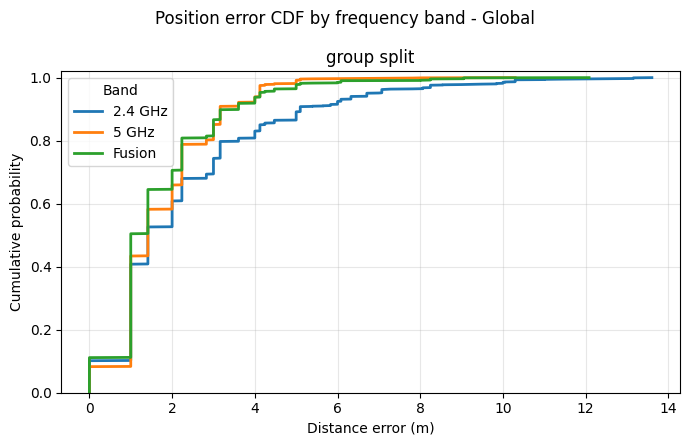

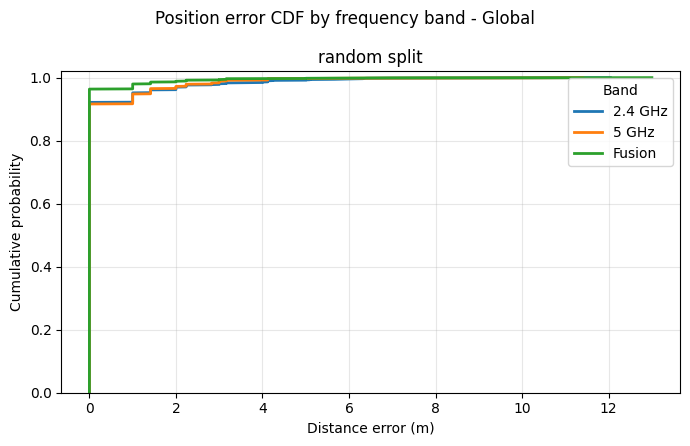

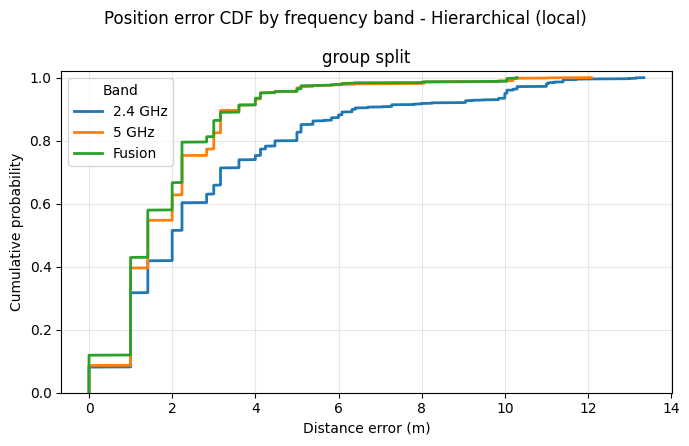

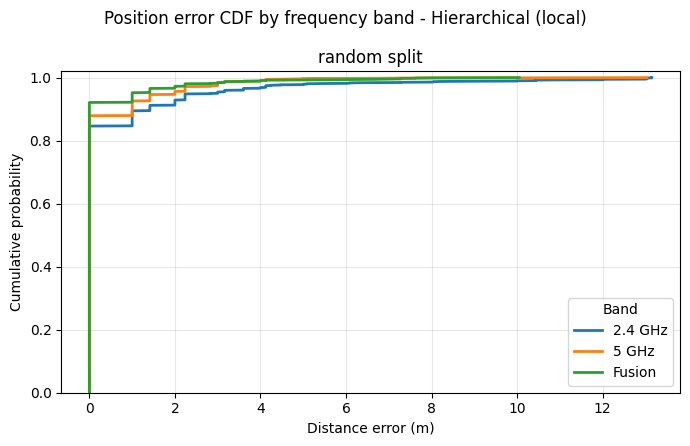

In [26]:
if SHOW_CDF_PLOTS:
    plot_band_error_cdf(global_all, model_label="Global", save_path=plots_dir)
    plot_band_error_cdf(hier_local_all, model_label="Hierarchical (local)", save_path=plots_dir)


### Box plot — distance error by frequency band

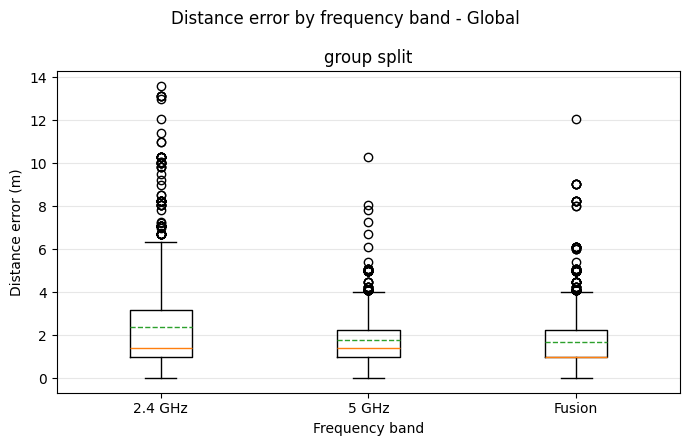

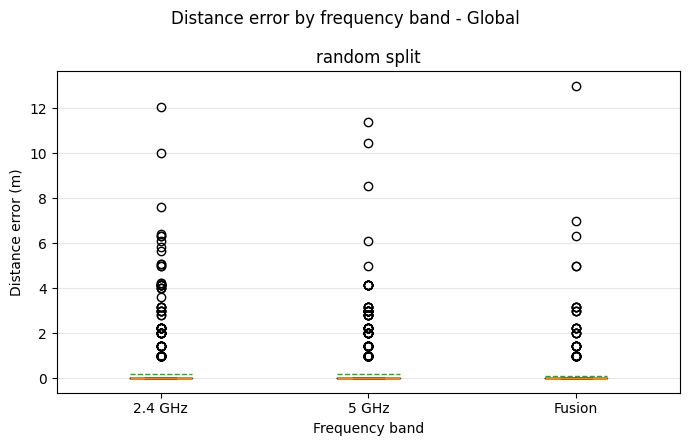

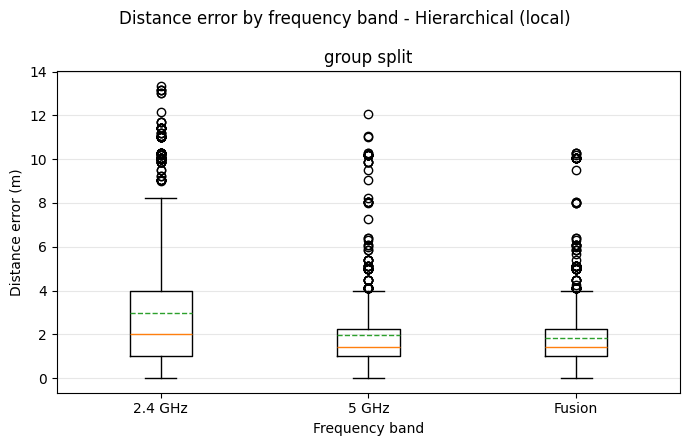

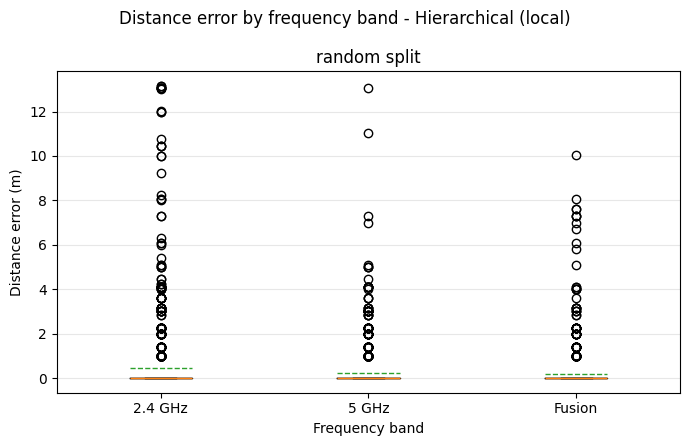

In [27]:
if SHOW_BOXPLOT:
    plot_band_error_boxplot(global_all, model_label="Global", save_path=plots_dir)
    plot_band_error_boxplot(
        hier_local_all, model_label="Hierarchical (local)", save_path=plots_dir
    )


## Floor Plan Heatmap

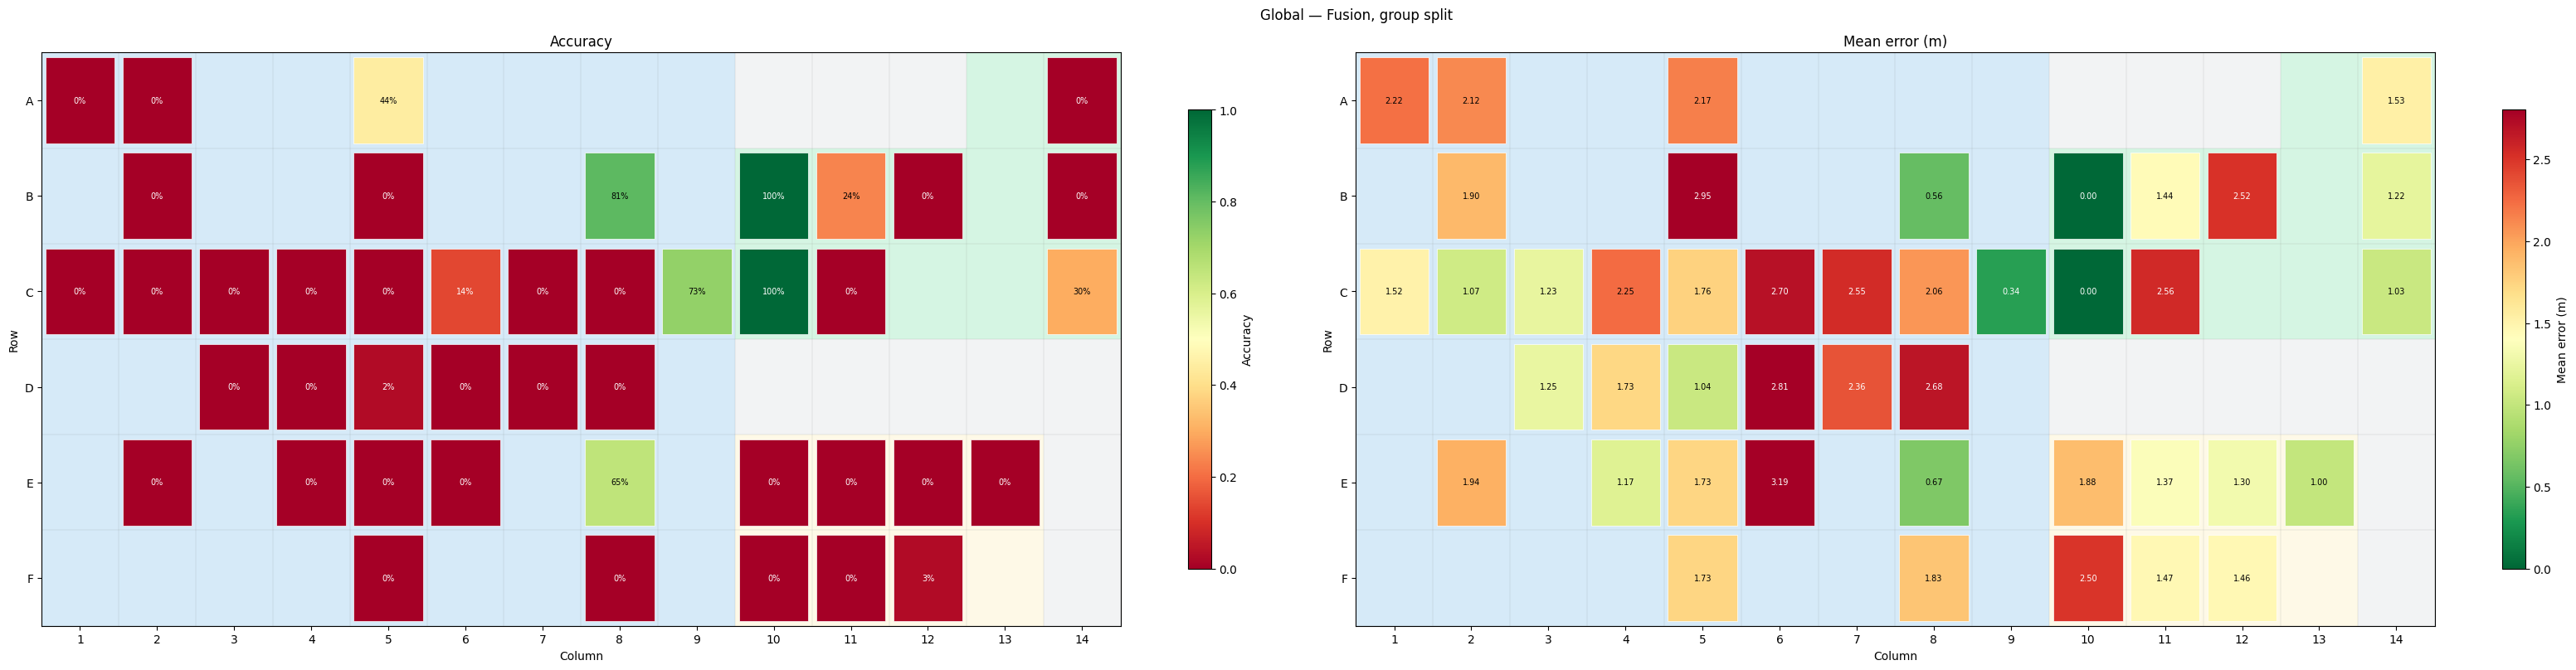

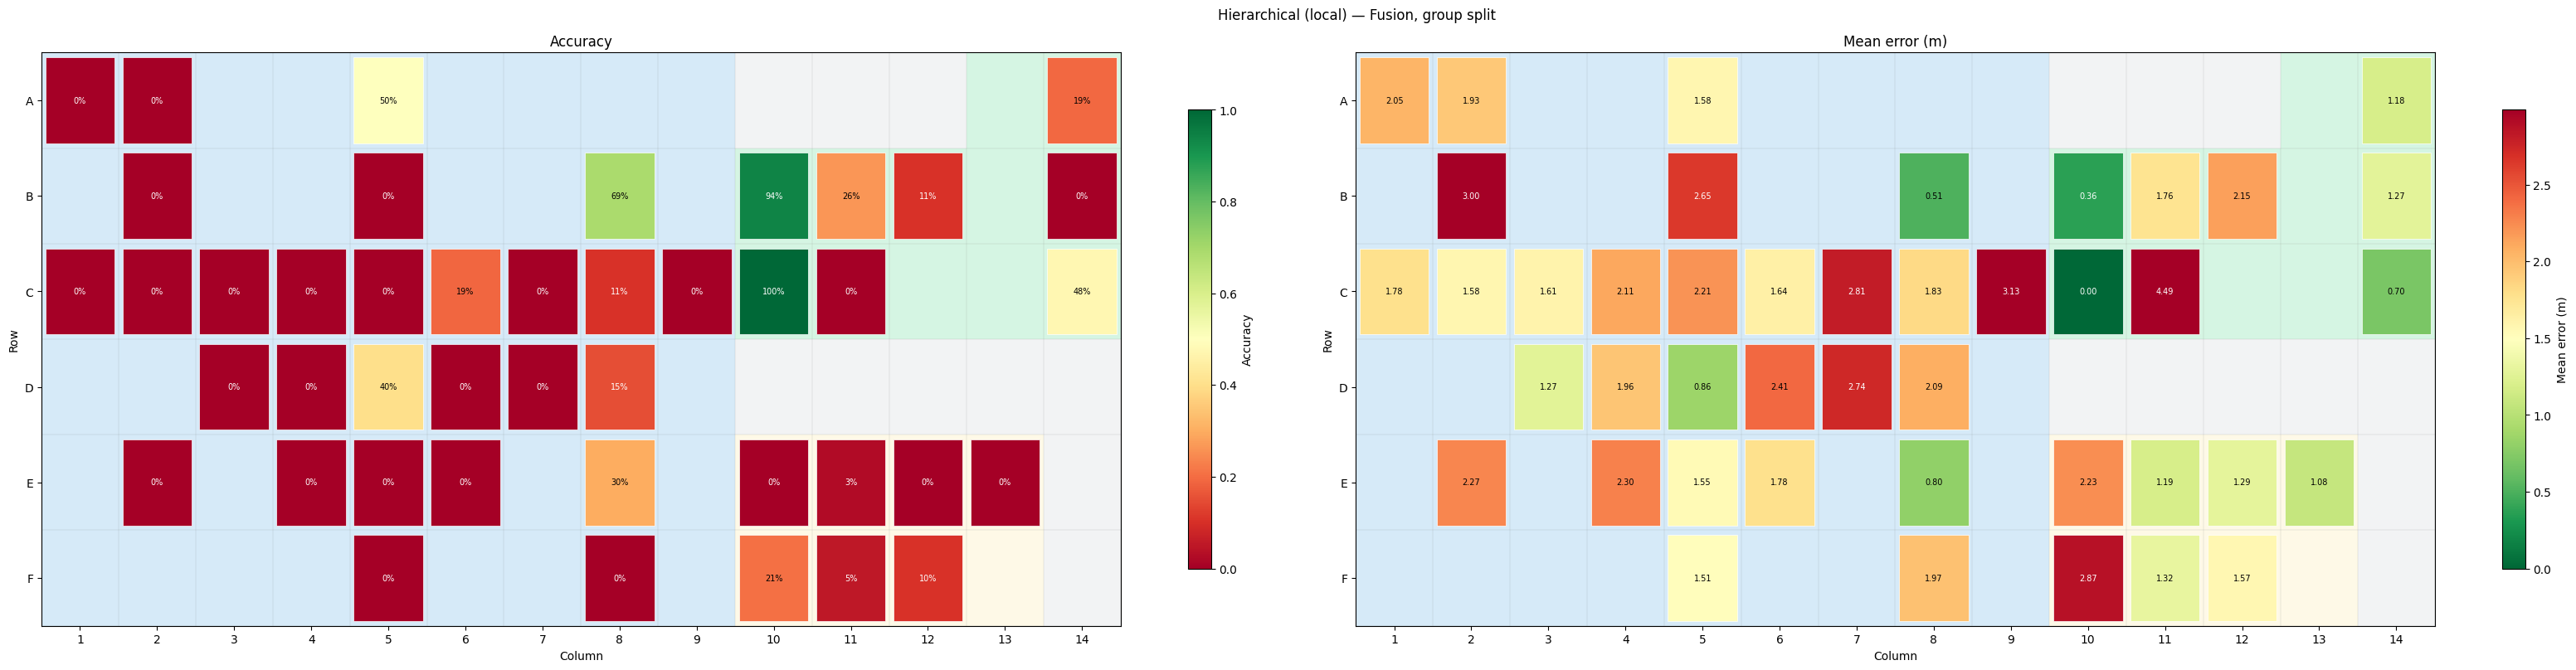

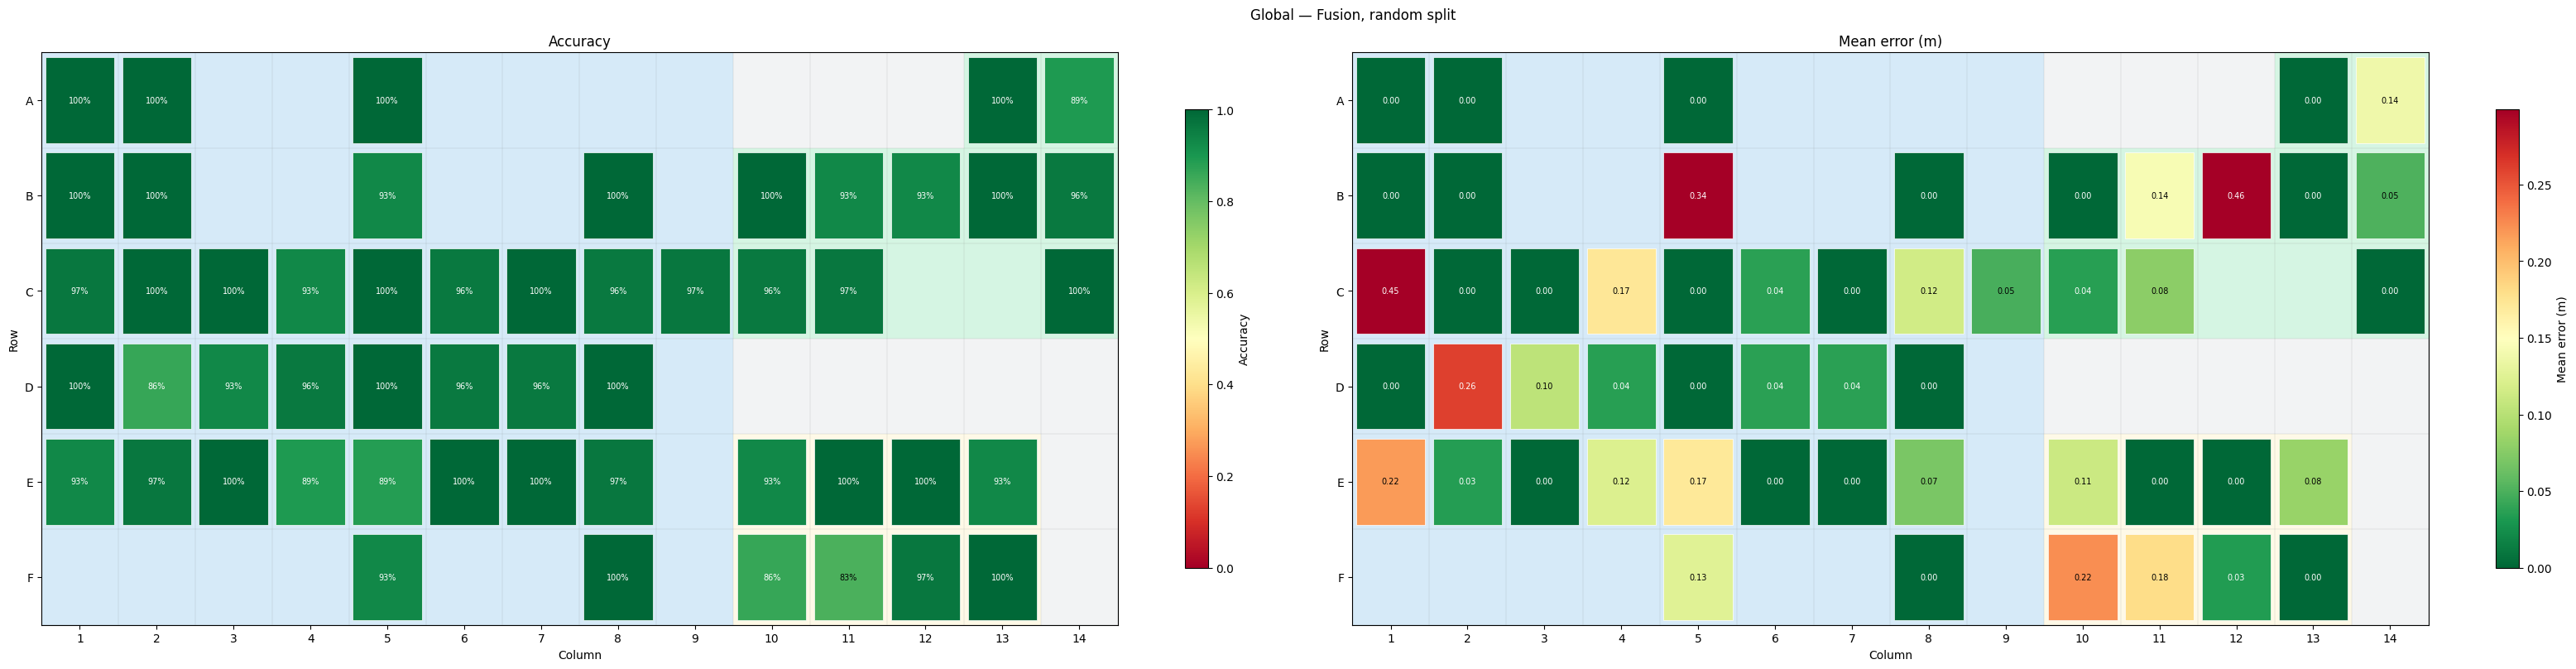

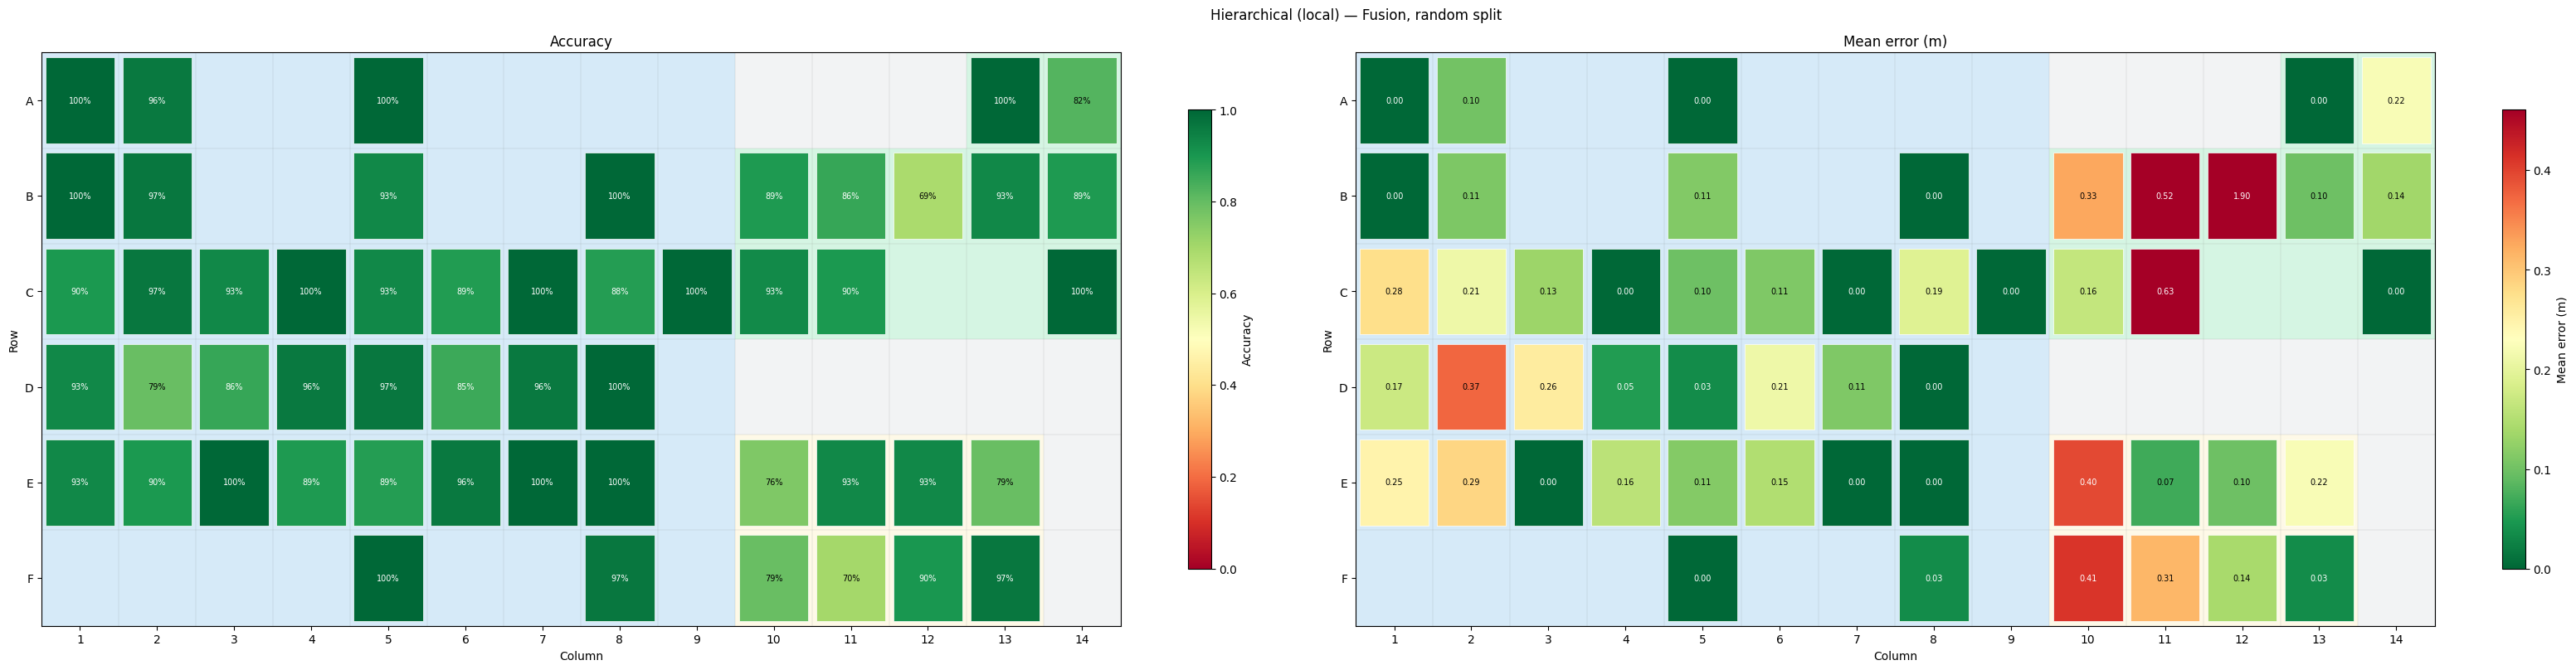

In [28]:
if SHOW_FLOOR_PLAN:
    for split_mode in SPLIT_MODES:
        for model_label, preds_dict in [
            ("Global", global_preds_by_split),
            ("Hierarchical (local)", hier_local_preds),
        ]:
            preds = preds_dict.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
            if preds.empty:
                print(f"No predictions for {model_label} / {CONFUSION_DATASET} / {split_mode}")
                continue
            fname = (
                f"floorplan_{_slugify(model_label)}"
                f"_{_slugify(CONFUSION_DATASET)}_{split_mode}.png"
            )
            plot_floor_plan_heatmap(
                preds,
                title=f"{model_label} — {CONFUSION_DATASET}, {split_mode} split",
                save_path=plots_dir / fname,
            )


## Position Confusion Matrices

In [29]:
if SHOW_CONFUSION_MATRICES:
    for model_label, preds_dict in [
        ("Global", global_preds_by_split),
        ("Hierarchical (local)", hier_local_preds),
    ]:
        for split_mode in SPLIT_MODES:
            preds = preds_dict.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
            if preds.empty:
                continue
            tagged = preds.assign(model=model_label)
            print(f"\n--- {model_label} / {CONFUSION_DATASET} / {split_mode} split ---")
            fname = (
                f"confusion_{_slugify(model_label)}"
                f"_{_slugify(CONFUSION_DATASET)}_{split_mode}.png"
            )
            plot_global_position_confusion_matrix(
                tagged,
                dataset=CONFUSION_DATASET,
                save_path=plots_dir / fname,
            )


## Per-Room Analysis — Hierarchical (local)

In [30]:
# Per-room accuracy and error breakdown for the local hierarchical model, both splits.
for split_mode in SPLIT_MODES:
    preds = hier_local_preds.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
    if preds.empty:
        print(f"No predictions for {CONFUSION_DATASET} / {split_mode}")
        continue
    print(f"\n=== Hierarchical (local) — {split_mode} split ===")
    display(per_room_hierarchical_summary(preds))

    if SHOW_PER_ROOM_PLOTS:
        tagged = preds.assign(model="Hierarchical (local)")
        plot_position_confusion_by_true_room(tagged, dataset=CONFUSION_DATASET)
        plot_position_confusion_when_room_correct(tagged, dataset=CONFUSION_DATASET)


=== Hierarchical (local) — group split ===


,dataset,true_room,samples,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,Fusion,2,260,0.907692,0.276923,1.849573,1.0,3.092174
1,Fusion,1,920,0.996739,0.094565,1.892042,2.0,2.254946
2,Fusion,3,290,0.920690,0.055172,1.644985,1.0,2.196392
3,Fusion,0,39,0.000000,0.000000,NaN,NaN,NaN



=== Hierarchical (local) — random split ===


,dataset,true_room,samples,room_accuracy,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,Fusion,1,966,1.000000,0.947205,0.104739,0.0,0.524750
1,Fusion,2,286,0.958042,0.891608,0.402192,0.0,1.539685
2,Fusion,3,234,0.995726,0.846154,0.210892,0.0,0.578588
3,Fusion,0,29,0.827586,0.827586,NaN,NaN,NaN


In [31]:
write_manifest(
    results_dir=results_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    classifier_params={
        "n_estimators": 300,
        "max_features": "sqrt",
        "random_state": RANDOM_STATE,
        "class_weight": "balanced",
    },
    splits=list(SPLIT_MODES),
    test_size=TEST_SIZE,
    feature_dataframes=feature_dataframes,
)


[results] Manifest written to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win120-step30\manifest.json
